# Dataset Analysis

In [ ]:
DATASET_PATH = "../dataset/dataset.json"
OUT_PATH      = "../results/bigcodebench_llm_clones.json" 
FILTERED_PATH_CODEBLEU = "../results/bigcodebench_llm_clones_filtered_codebleu.json" 
FILTERED_PATH_REPROMPT = "../results/bigcodebench_llm_clones_filtered_reprompt.json" 
FILTERED_PATH_TESTS = "../results/bigcodebench_llm_clones_filtered_tests.json" 
FINAL_DATASET = "../results/bigcodebench_clone_dataset.json"  
from src.utils import CODEBLEU_THRESHOLD


## Refactorings

In [166]:
import json
import numpy as np
from collections import Counter
 

# === LOAD DATA ===
with open(OUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

if isinstance(data, dict):  # ensure list
    data = [data]

# === COUNT REFACTORINGS ===
refac_counter = Counter()

for entry in data:
    for clone in entry.get("clones", []):
        refacs = clone.get("refacs", [])
        if isinstance(refacs, list):
            refac_counter.update(refacs)
        elif isinstance(refacs, str):
            refac_counter[refacs] += 1

# === COMPUTE STATISTICS ===
counts = list(refac_counter.values())

if not counts:
    print("⚠️ No refactoring data found.")
else:
    min_count = min(counts)
    max_count = max(counts)
    avg_count = np.mean(counts)
    std_count = np.std(counts) 

    print("=== Individual Refactoring Counts ===")
    for refac, count in sorted(refac_counter.items(), key=lambda x: x[0]):
        print(f"{refac}: {count}")


=== Individual Refactoring Counts ===
refac_1: 360
refac_2: 360
refac_3: 360
refac_4: 360
refac_5: 360
refac_6: 360
refac_7: 360


## Overal

### Codebleu

Average fraction of clones per entry below CodeBLEU threshold 0.4: 0.551


C:\Users\lamp6\AppData\Local\Temp\ipykernel_21024\96271027.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
C:\Users\lamp6\AppData\Local\Temp\ipykernel_21024\96271027.py:74: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(
C:\Users\lamp6\AppData\Local\Temp\ipykernel_21024\96271027.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


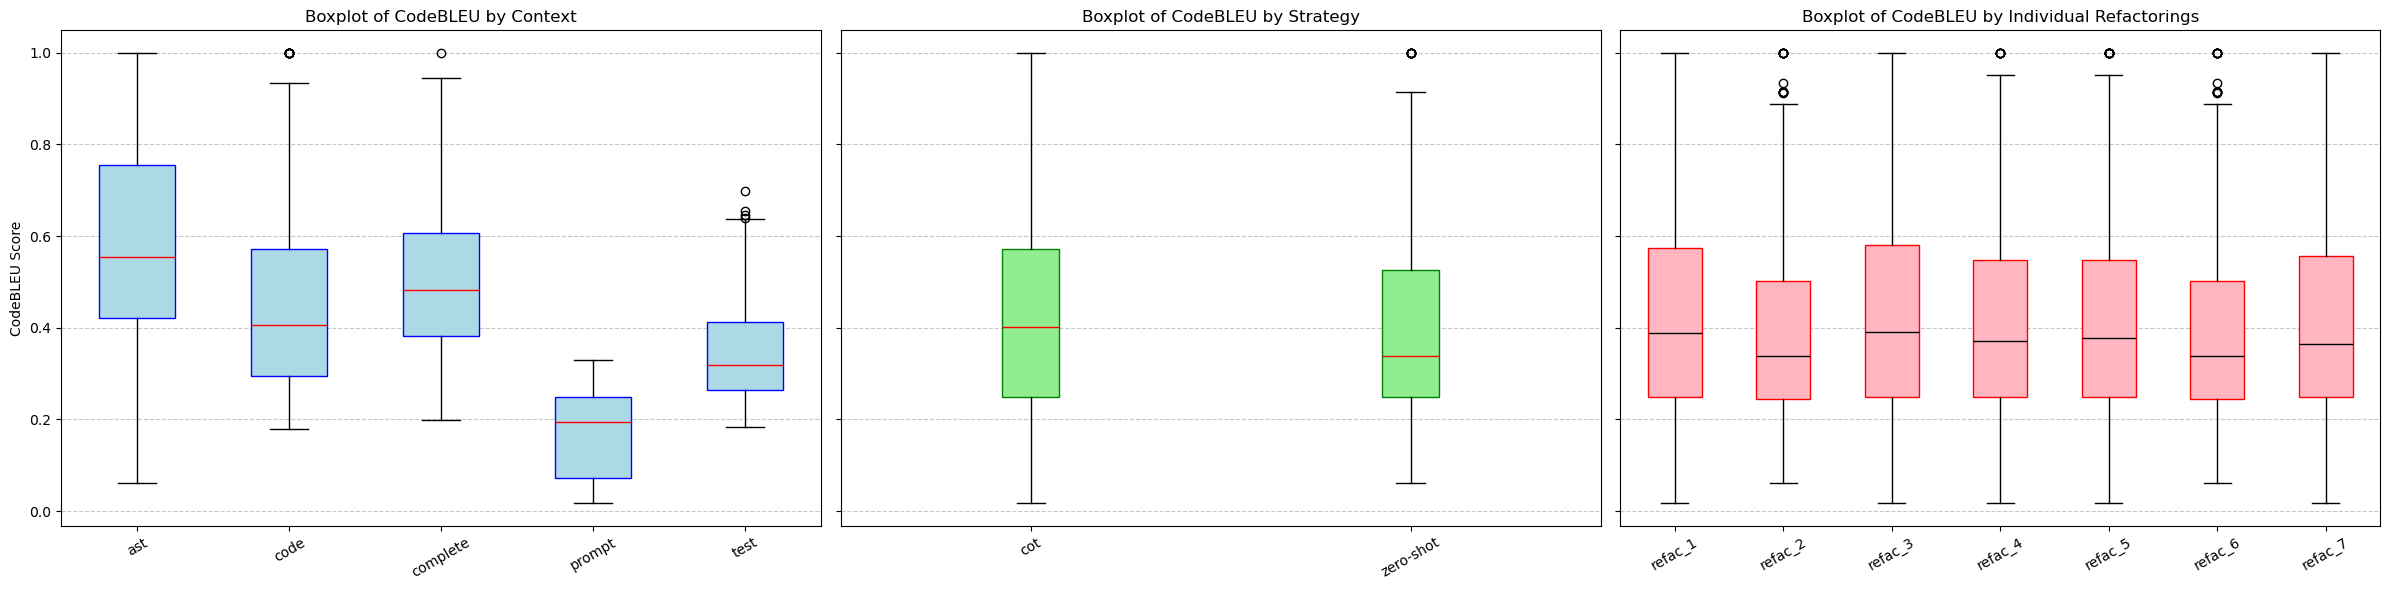

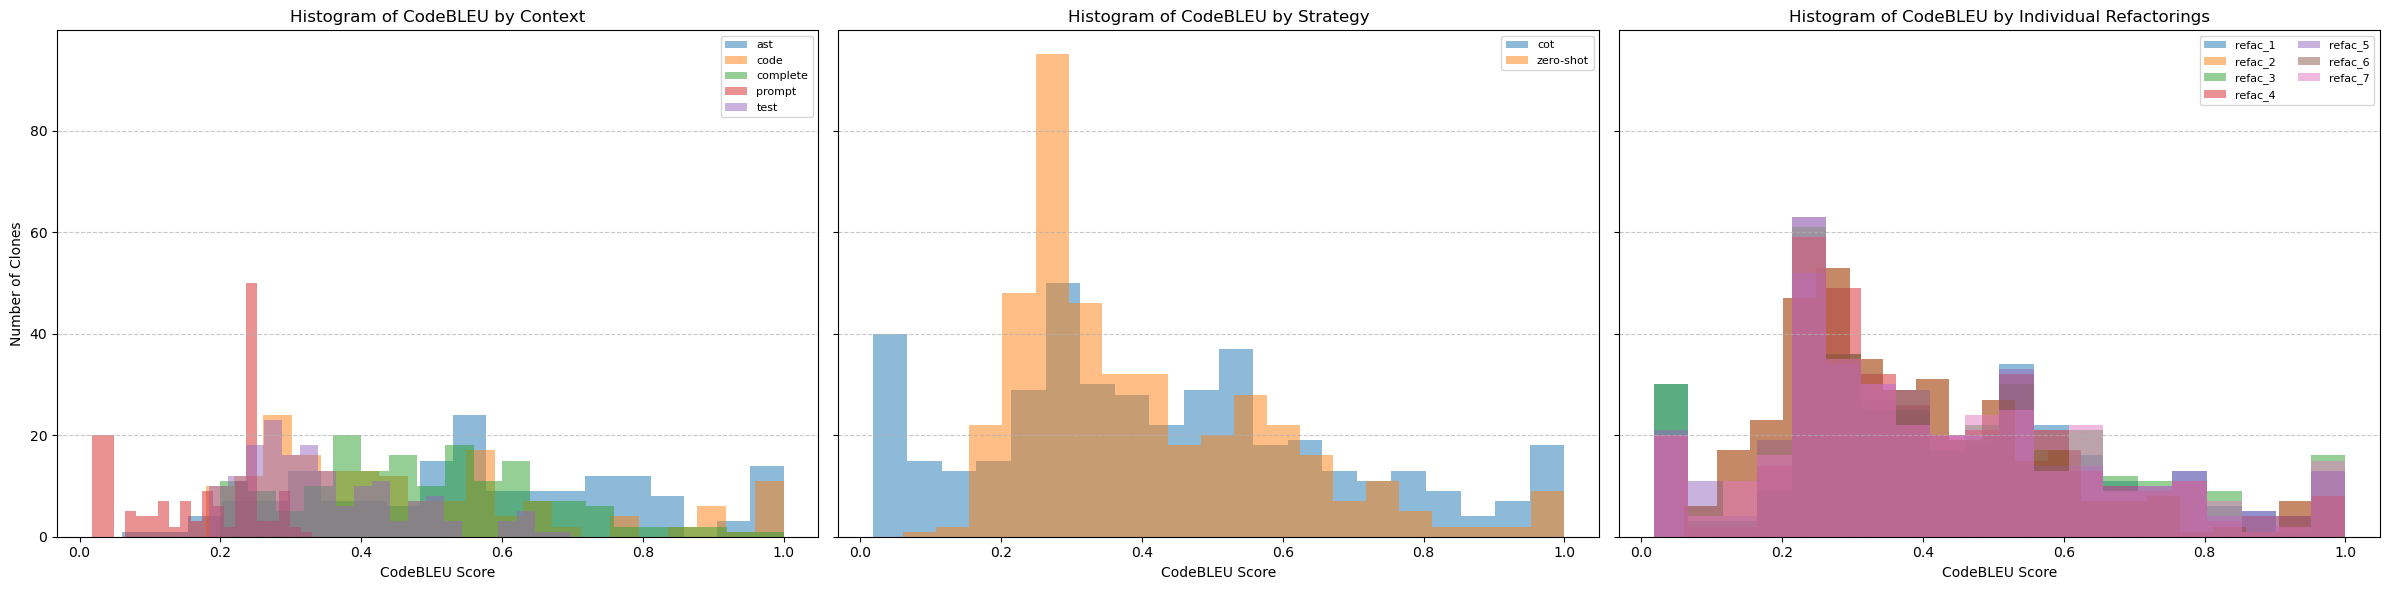

In [169]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict
 

# --- Load dataset ---
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# --- Collect scores ---
scores_by_context = defaultdict(list)
scores_by_strategy = defaultdict(list)
scores_by_refac = defaultdict(list)

# --- Track counts of clones below threshold per entry ---
below_threshold_counts = []

for entry in dataset:
    clones = entry.get("clones", [])
    count_below = 0
    for clone in clones:
        context = clone.get("context", "unknown")
        strategy = clone.get("strategy", "unknown")
        refacs_list = clone.get("refacs")
        score_dict = clone.get("metrics", {}).get("codebleu", {})
        score = score_dict.get("originalcode")
        if score is None:
            continue

        # Count if below threshold
        if score <= CODEBLEU_THRESHOLD:
            count_below += 1

        # Context and strategy
        scores_by_context[context].append(score)
        scores_by_strategy[strategy].append(score)

        # Individual refacs
        if refacs_list and isinstance(refacs_list, list):
            for refac in refacs_list:
                scores_by_refac[refac].append(score)

     

# --- Total clones and those below threshold ---
total_clones = sum(len(entry.get("clones", [])) for entry in dataset)
total_below_threshold = sum(
    1
    for entry in dataset
    for clone in entry.get("clones", [])
    if clone.get("metrics", {}).get("codebleu", {}).get("originalcode", 1.0) <= CODEBLEU_THRESHOLD
)

percentage_below = (total_below_threshold / total_clones * 100) if total_clones else 0.0

print(f"Total clones: {total_clones}")
print(f"Clones below CodeBLEU threshold ({CODEBLEU_THRESHOLD}): {total_below_threshold}")
print(f"Percentage below threshold: {percentage_below:.2f}%")


# --- Sort labels for consistency ---
sorted_contexts = sorted(scores_by_context.keys())
sorted_strategies = sorted(scores_by_strategy.keys())
sorted_refacs = sorted(scores_by_refac.keys())

# --- Boxplots ---
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

# Context
data_context = [scores_by_context[c] for c in sorted_contexts]
axes[0].boxplot(
    data_context, vert=True, patch_artist=True,
    labels=sorted_contexts,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red")
)
axes[0].set_title("Boxplot of CodeBLEU by Context")
axes[0].set_ylabel("CodeBLEU Score")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Strategy
data_strategy = [scores_by_strategy[s] for s in sorted_strategies]
axes[1].boxplot(
    data_strategy, vert=True, patch_artist=True,
    labels=sorted_strategies,
    boxprops=dict(facecolor="lightgreen", color="green"),
    medianprops=dict(color="red")
)
axes[1].set_title("Boxplot of CodeBLEU by Strategy")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# Refacs
data_refac = [scores_by_refac[r] for r in sorted_refacs if scores_by_refac[r]]
axes[2].boxplot(
    data_refac, vert=True, patch_artist=True,
    labels=[r for r in sorted_refacs if scores_by_refac[r]],
    boxprops=dict(facecolor="lightpink", color="red"),
    medianprops=dict(color="black")
)
axes[2].set_title("Boxplot of CodeBLEU by Individual Refactorings")
axes[2].tick_params(axis="x", rotation=30)
axes[2].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

# --- Histograms ---
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

# Context
for c in sorted_contexts:
    axes[0].hist(scores_by_context[c], bins=20, alpha=0.5, label=c)
axes[0].set_title("Histogram of CodeBLEU by Context")
axes[0].set_xlabel("CodeBLEU Score")
axes[0].set_ylabel("Number of Clones")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Strategy
for s in sorted_strategies:
    axes[1].hist(scores_by_strategy[s], bins=20, alpha=0.5, label=s)
axes[1].set_title("Histogram of CodeBLEU by Strategy")
axes[1].set_xlabel("CodeBLEU Score")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# Refacs
for r in sorted_refacs:
    if scores_by_refac[r]:
        axes[2].hist(scores_by_refac[r], bins=20, alpha=0.5, label=r)
axes[2].set_title("Histogram of CodeBLEU by Individual Refactorings")
axes[2].set_xlabel("CodeBLEU Score")
axes[2].legend(fontsize=8, ncol=2)
axes[2].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


### Tests

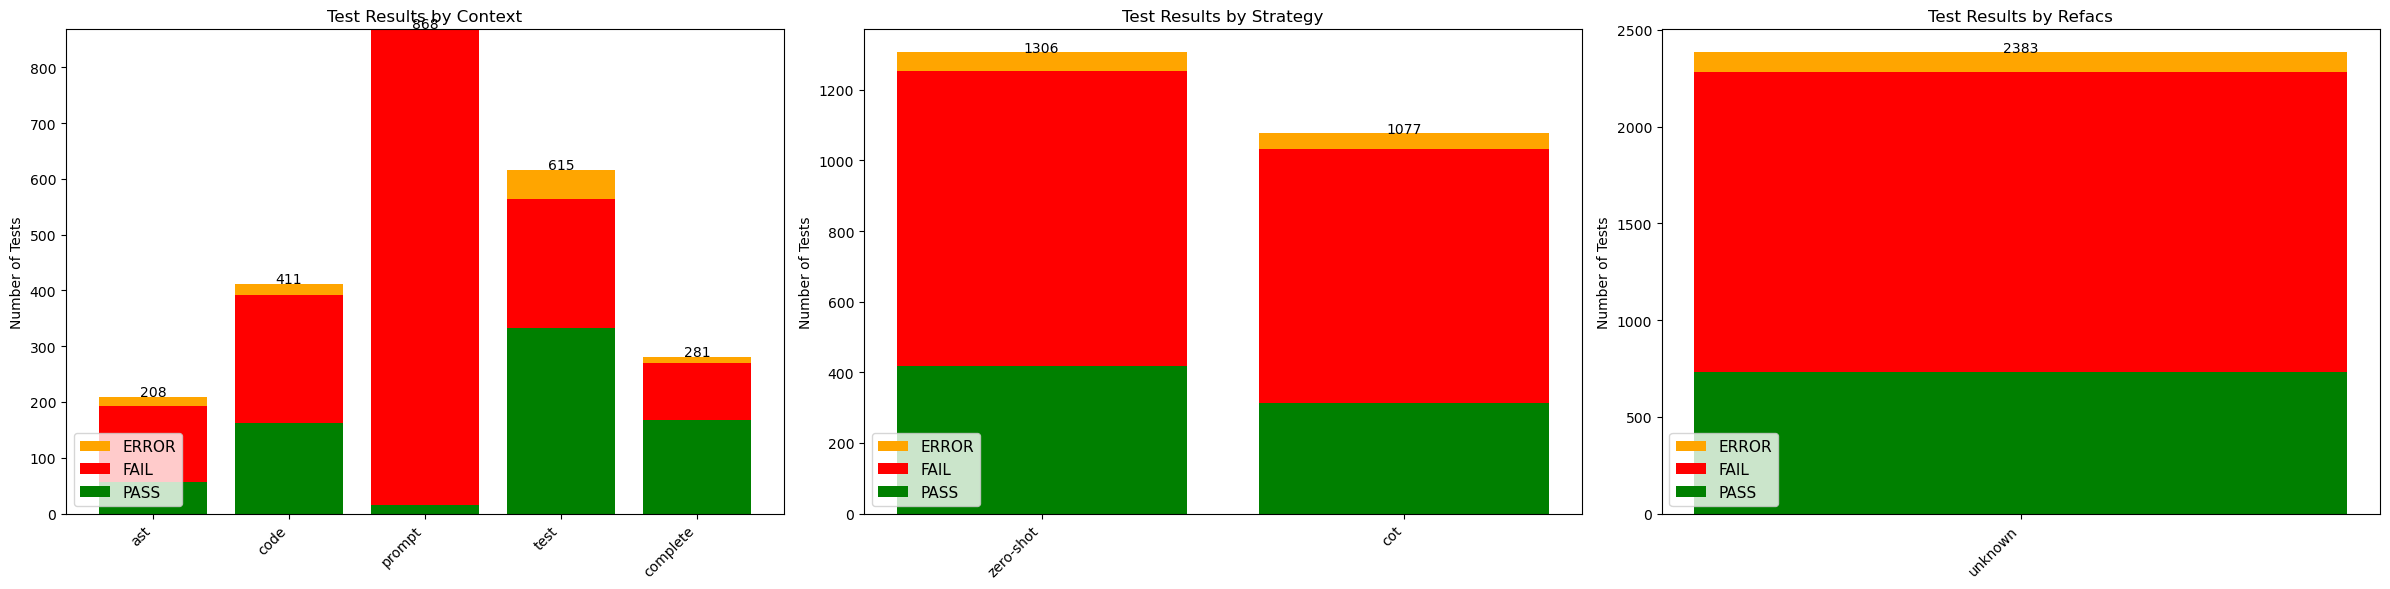

In [167]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(FILTERED_PATH_CODEBLEU, "r", encoding="utf-8") as f:
    dataset = json.load(f)
 
# Initialize dictionaries for grouping
grouped_by_context = {}
grouped_by_refacs = {}
grouped_by_strategy = {}

for entry in dataset:
    # Determine expected number of tests for this entry
    if entry.get("clones"):
        num_tests = max(len(clone.get("test_results", {})) for clone in entry["clones"])
    else:
        num_tests = 0

    for clone in entry.get("clones", []):
        context = clone.get("context", "unknown")
        refacs = clone.get("refac", "unknown")
        strategy = clone.get("strategy", "unknown")
        results = clone.get("test_results", {})

        # Fill missing tests as ERROR
        if len(results) < num_tests:
            missing = num_tests - len(results)
            for i in range(missing):
                results[f"missing_test_{i+1}"] = "ERROR"

        # --- Group by context ---
        if context not in grouped_by_context:
            grouped_by_context[context] = {"PASS": 0, "FAIL": 0, "ERROR": 0}
        for status in results.values():
            status = status.upper()
            if status in ["PASS", "FAIL", "ERROR"]:
                grouped_by_context[context][status] += 1

        
        # --- Group by Refac ---
        if refacs not in grouped_by_refacs:
            grouped_by_refacs[refacs] = {"PASS": 0, "FAIL": 0, "ERROR": 0}
        for status in results.values():
            status = status.upper()
            if status in ["PASS", "FAIL", "ERROR"]:
                grouped_by_refacs[refacs][status] += 1

        # --- Group by strategy ---
        if strategy not in grouped_by_strategy:
            grouped_by_strategy[strategy] = {"PASS": 0, "FAIL": 0, "ERROR": 0}
        for status in results.values():
            status = status.upper()
            if status in ["PASS", "FAIL", "ERROR"]:
                grouped_by_strategy[strategy][status] += 1


# Function to prepare data for plotting
def prepare_data(grouped_dict):
    filters = list(grouped_dict.keys())
    passes = [grouped_dict[h]["PASS"] for h in filters]
    fails  = [grouped_dict[h]["FAIL"] for h in filters]
    errors = [grouped_dict[h]["ERROR"] for h in filters]
    return filters, passes, fails, errors


# Prepare data
filters_context, passes_context, fails_context, errors_context = prepare_data(grouped_by_context)
filters_strategy, passes_strategy, fails_strategy, errors_strategy = prepare_data(grouped_by_strategy)
filters_refacs, passes_refacs, fails_refacs, errors_refacs = prepare_data(grouped_by_refacs)


# Create subplots (3 panels)
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# --- Plot context ---
x_context = range(len(filters_context))
axes[0].bar(x_context, passes_context, color="green", label="PASS")
axes[0].bar(x_context, fails_context, bottom=passes_context, color="red", label="FAIL")
axes[0].bar(x_context, errors_context, bottom=[p+f for p, f in zip(passes_context, fails_context)], color="orange", label="ERROR")
axes[0].set_xticks(x_context)
axes[0].set_xticklabels(filters_context, rotation=45, ha="right")
axes[0].set_ylabel("Number of Tests")
axes[0].set_title("Test Results by Context")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[::-1], labels[::-1], fontsize=11, loc="lower left")
for i, (p, f, e) in enumerate(zip(passes_context, fails_context, errors_context)):
    total = p + f + e
    axes[0].text(i, total + 2, str(total), ha="center", fontsize=10)



# --- Plot refacs ---
x_refacs = range(len(filters_refacs))
axes[2].bar(x_refacs, passes_refacs, color="green", label="PASS")
axes[2].bar(x_refacs, fails_refacs, bottom=passes_refacs, color="red", label="FAIL")
axes[2].bar(x_refacs, errors_refacs, bottom=[p+f for p, f in zip(passes_refacs, fails_refacs)], color="orange", label="ERROR")
axes[2].set_xticks(x_refacs)
axes[2].set_xticklabels(filters_refacs, rotation=45, ha="right")
axes[2].set_ylabel("Number of Tests")
axes[2].set_title("Test Results by Refacs")
handles, labels = axes[2].get_legend_handles_labels()
axes[2].legend(handles[::-1], labels[::-1], fontsize=11, loc="lower left")
for i, (p, f, e) in enumerate(zip(passes_refacs, fails_refacs, errors_refacs)):
    total = p + f + e
    axes[2].text(i, total + 2, str(total), ha="center", fontsize=10)

# --- Plot strategies ---
x_strategy = range(len(filters_strategy))
axes[1].bar(x_strategy, passes_strategy, color="green", label="PASS")
axes[1].bar(x_strategy, fails_strategy, bottom=passes_strategy, color="red", label="FAIL")
axes[1].bar(x_strategy, errors_strategy, bottom=[p+f for p, f in zip(passes_strategy, fails_strategy)], color="orange", label="ERROR")
axes[1].set_xticks(x_strategy)
axes[1].set_xticklabels(filters_strategy, rotation=45, ha="right")
axes[1].set_ylabel("Number of Tests")
axes[1].set_title("Test Results by Strategy")
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles[::-1], labels[::-1], fontsize=11, loc="lower left")
for i, (p, f, e) in enumerate(zip(passes_strategy, fails_strategy, errors_strategy)):
    total = p + f + e
    axes[1].text(i, total + 2, str(total), ha="center", fontsize=10)

plt.tight_layout()
plt.show()


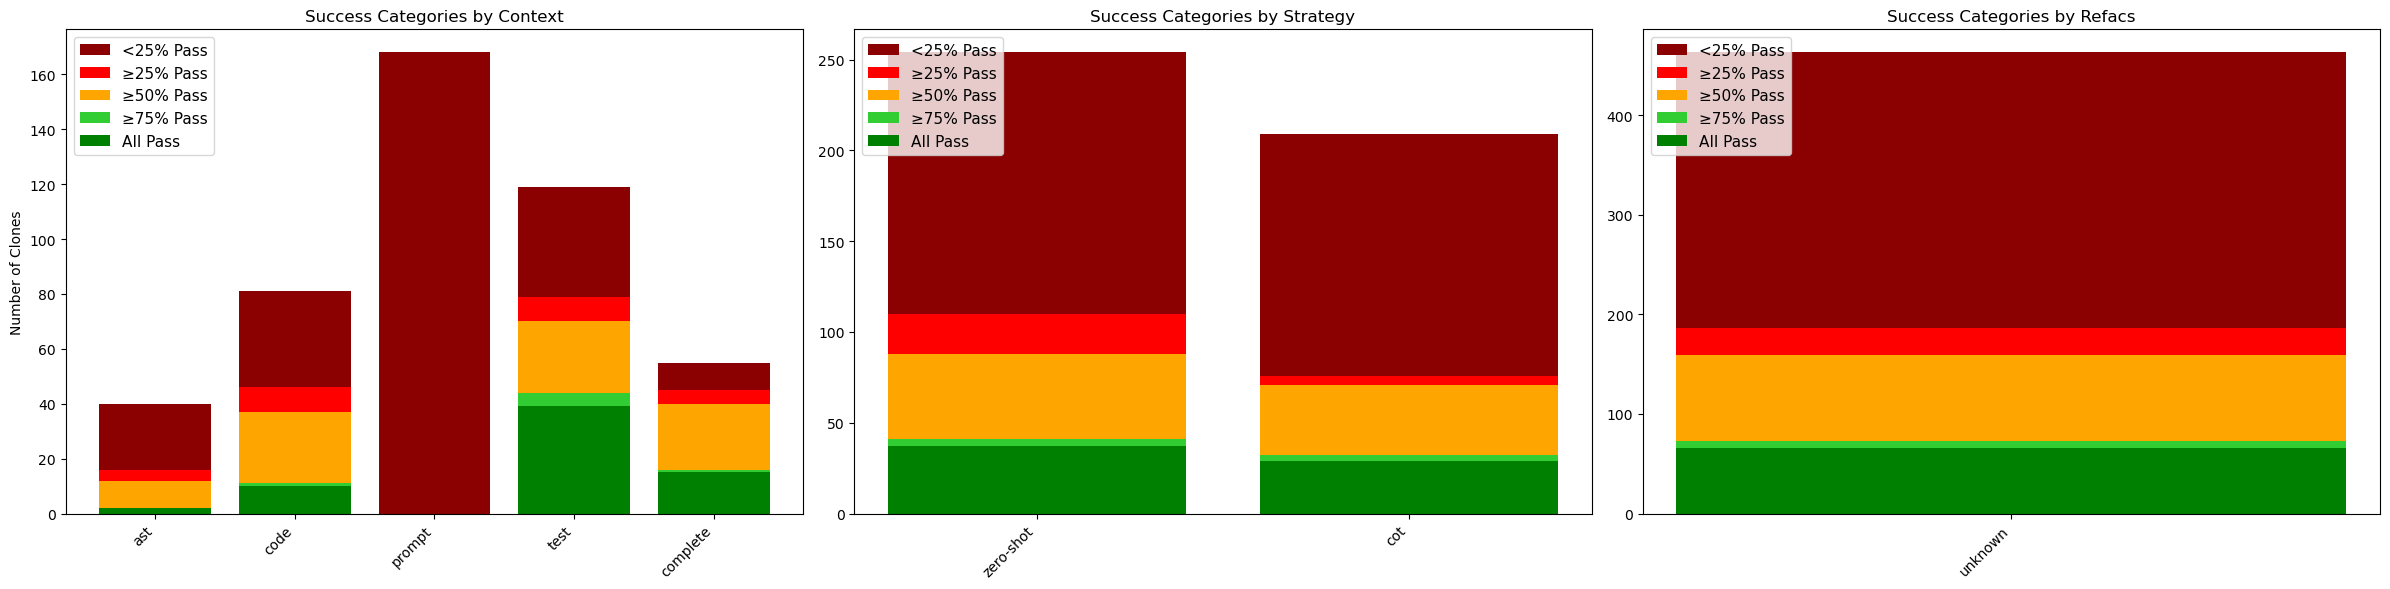

In [168]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(FILTERED_PATH_CODEBLEU, "r", encoding="utf-8") as f:
    dataset = json.load(f)

categories = ["All Pass", "≥75% Pass", "≥50% Pass", "≥25% Pass", "<25% Pass"]

def classify_clone(results, num_tests):
    num_pass = sum(1 for v in results.values() if v.upper() == "PASS")
    ratio = num_pass / num_tests if num_tests > 0 else 0

    if ratio == 1.0:
        return "All Pass"
    elif ratio >= 0.75:
        return "≥75% Pass"
    elif ratio >= 0.50:
        return "≥50% Pass"
    elif ratio >= 0.25:
        return "≥25% Pass"
    else:
        return "<25% Pass"

# Initialize grouping
grouped_context = {} 
grouped_refacs = {}
grouped_strategy = {}

for entry in dataset:
    if entry.get("clones"):
        num_tests = max(len(clone.get("test_results", {})) for clone in entry["clones"])
    else:
        num_tests = 0

    for clone in entry.get("clones", []):
        context = clone.get("context", "unknown")
        refacs = clone.get("refac", "unknown")
        strategy = clone.get("strategy", "unknown")  # <-- NEW
        results = clone.get("test_results", {})

        if len(results) < num_tests:
            for i in range(num_tests - len(results)):
                results[f"missing_test_{i+1}"] = "ERROR"

        category = classify_clone(results, num_tests)

        # Group by context
        if context not in grouped_context:
            grouped_context[context] = {c: 0 for c in categories}
        grouped_context[context][category] += 1 

        # Group by refac
        if refacs not in grouped_refacs:
            grouped_refacs[refacs] = {c: 0 for c in categories}
        grouped_refacs[refacs][category] += 1

        # Group by strategy
        if strategy not in grouped_strategy:
            grouped_strategy[strategy] = {c: 0 for c in categories}
        grouped_strategy[strategy][category] += 1


def plot_grouped(ax, grouped_dict, title):
    filters = list(grouped_dict.keys())
    x = range(len(filters))

    bottoms = [0] * len(filters)
    for cat, color in zip(categories,
                          ["green", "limegreen", "orange", "red", "darkred"]):
        values = [grouped_dict[f][cat] for f in filters]
        ax.bar(x, values, bottom=bottoms, label=cat, color=color)
        bottoms = [b + v for b, v in zip(bottoms, values)]

    ax.set_xticks(x)
    ax.set_xticklabels(filters, rotation=45, ha="right", fontsize=10)
    ax.set_title(title)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], fontsize=11, loc="upper left")


fig, axes = plt.subplots(1, 3, figsize=(24, 6))

plot_grouped(axes[0], grouped_context, "Success Categories by Context") 
plot_grouped(axes[2], grouped_refacs, "Success Categories by Refacs")
plot_grouped(axes[1], grouped_strategy, "Success Categories by Strategy")

axes[0].set_ylabel("Number of Clones")

plt.tight_layout()
plt.show()


### Reprompt

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

 

# --- Load both datasets ---
with open(FILTERED_PATH_CODEBLEU, "r", encoding="utf-8") as f:
    before_data = json.load(f)

with open(FILTERED_PATH_REPROMPT, "r", encoding="utf-8") as f:
    after_data = json.load(f)

# --- Index clones by (entry_id, clone_id) for easy lookup ---
def index_clones(dataset):
    index = {}
    for entry in dataset:
        entry_id = entry.get("id")
        for clone in entry.get("clones", []):
            clone_id = clone.get("clone_id")
            index[(entry_id, clone_id)] = clone
    return index

before_index = index_clones(before_data)
after_index = index_clones(after_data)

# --- Collect data ---
clone_ids = []
before_pass_counts = []
after_pass_counts = []

for key, before_clone in before_index.items():
    after_clone = after_index.get(key)
    if not after_clone:
        continue  # skip if clone not found after reprompt

    before_results = before_clone.get("test_results", {})
    after_results = after_clone.get("test_results", {})

    # Count passes
    before_pass = sum(1 for r in before_results.values() if isinstance(r, str) and r.upper() == "PASS")
    after_pass = sum(1 for r in after_results.values() if isinstance(r, str) and r.upper() == "PASS")

    clone_ids.append(f"{key[0]}-{key[1]}")
    before_pass_counts.append(before_pass)
    after_pass_counts.append(after_pass)

# --- Plot ---
x = np.arange(len(clone_ids))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, before_pass_counts, width, label="Before Reprompt", color="lightcoral")
plt.bar(x + width/2, after_pass_counts, width, label="After Reprompt", color="mediumseagreen")

plt.title("Number of Passing Tests per Clone: Before vs After Reprompt")
plt.xlabel("Clone (entry_id–clone_id)")
plt.ylabel("Number of Passing Tests")
plt.xticks(x, clone_ids, rotation=90)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- Summary Stats ---
total_before = sum(before_pass_counts)
total_after = sum(after_pass_counts)
improvement = total_after - total_before
pct_increase = (improvement / total_before * 100) if total_before else 0.0

print(f"Total passing tests before: {total_before}")
print(f"Total passing tests after:  {total_after}")
print(f"Improvement: +{improvement} ({pct_increase:.2f}%)")


## Per LLM

### Codebleu

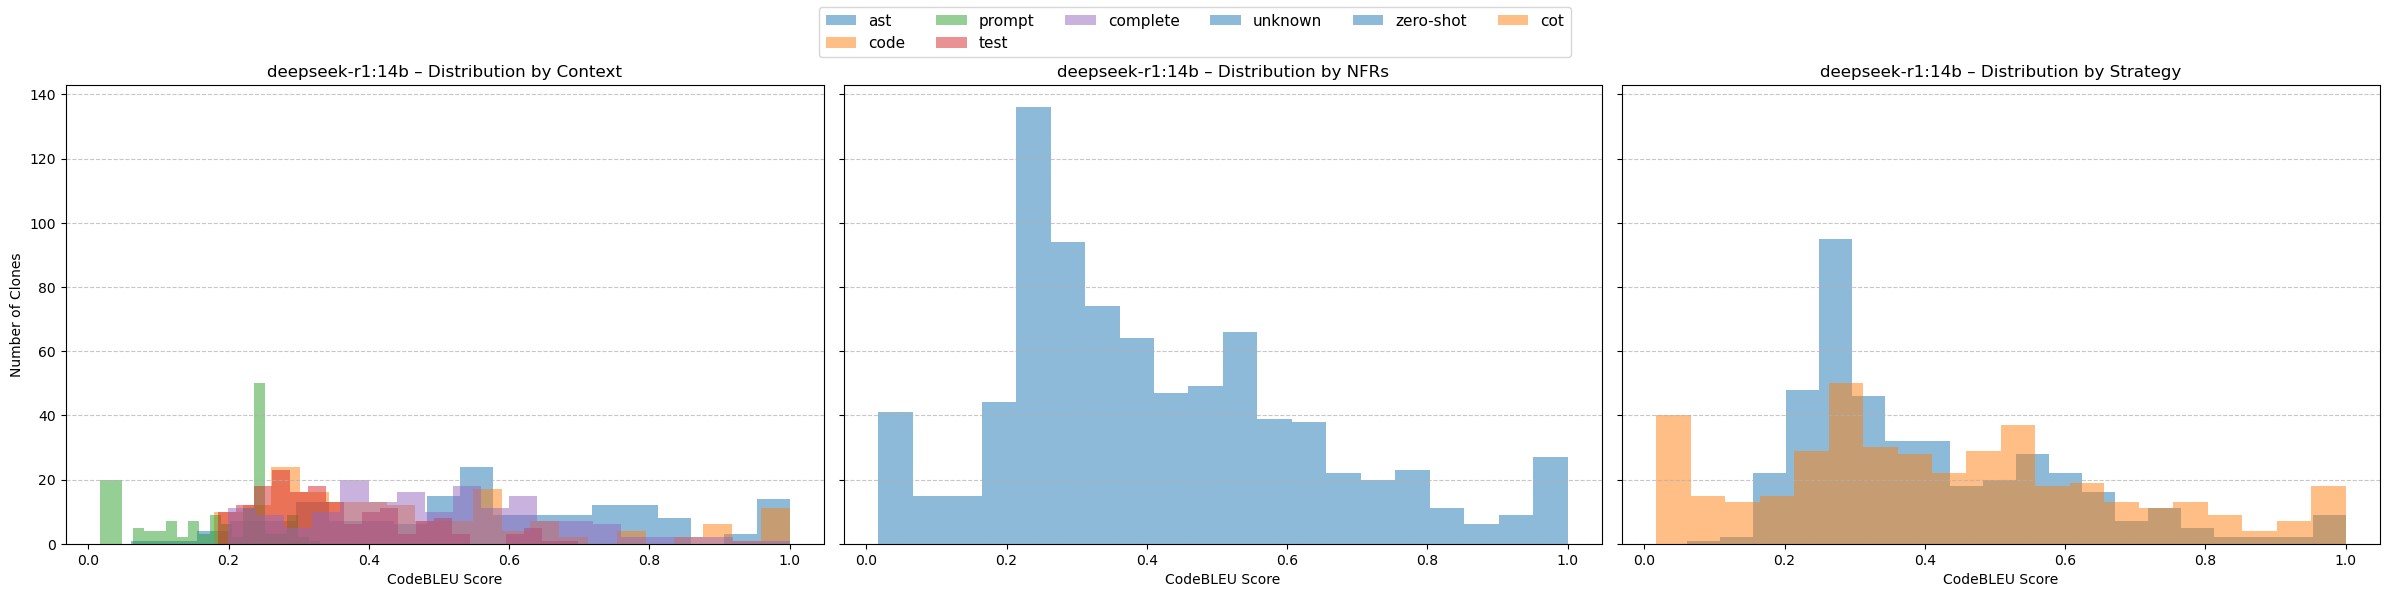

C:\Users\lamp6\AppData\Local\Temp\ipykernel_21024\42667716.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_context, vert=True, patch_artist=True,
C:\Users\lamp6\AppData\Local\Temp\ipykernel_21024\42667716.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_nfrs, vert=True, patch_artist=True,
C:\Users\lamp6\AppData\Local\Temp\ipykernel_21024\42667716.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(data_strat, vert=True, patch_artist=True,


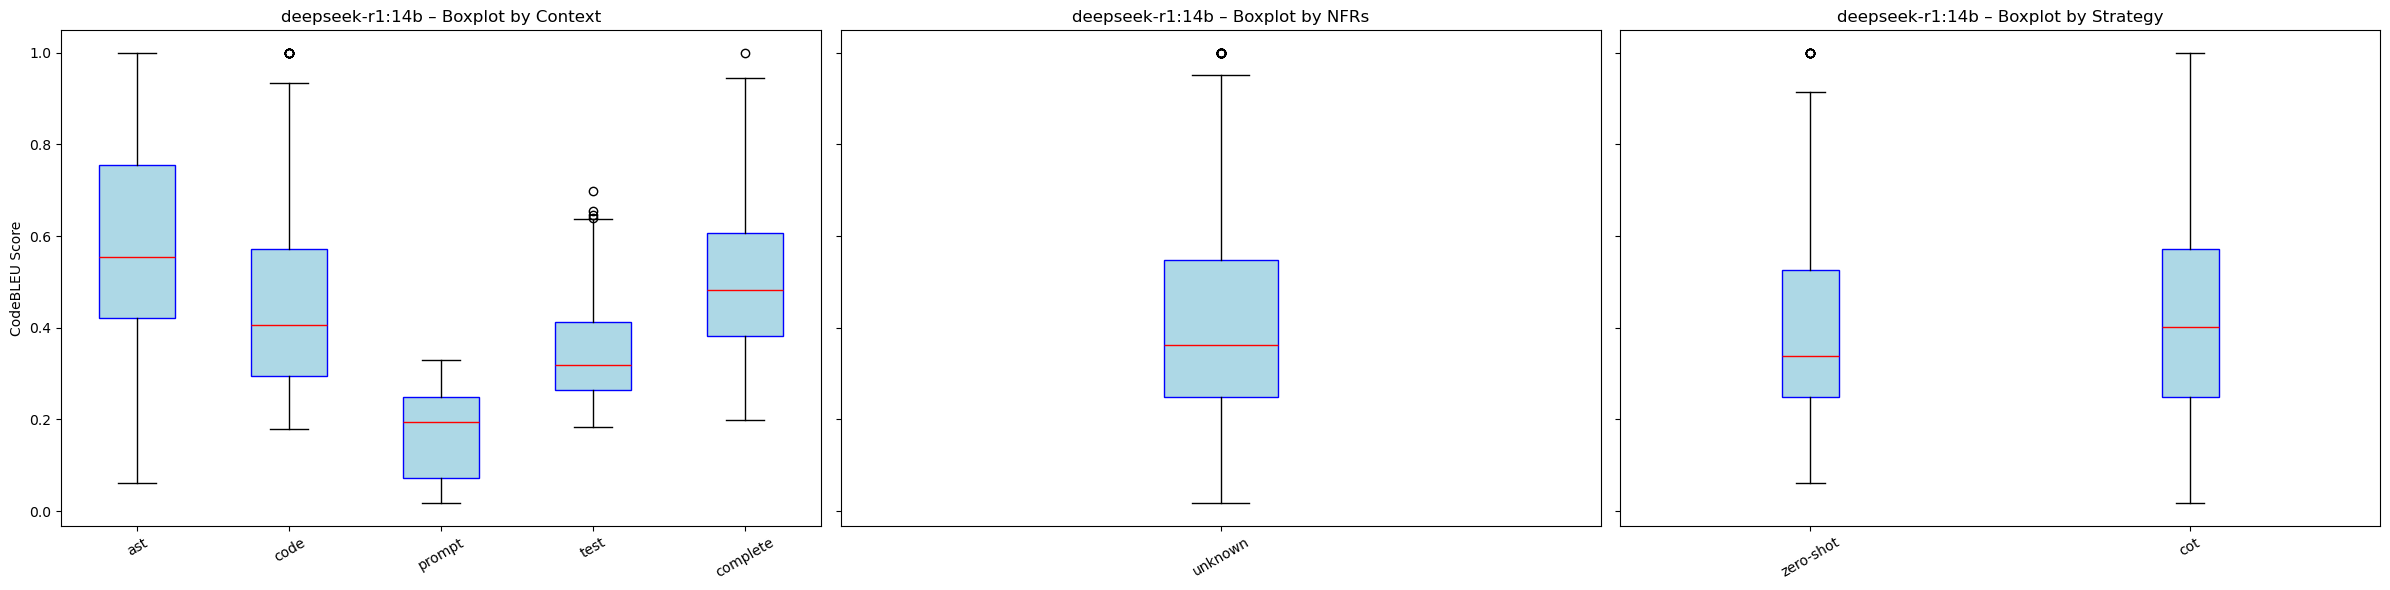

In [172]:
import json
import matplotlib.pyplot as plt
 

# Load dataset
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# Collect CodeBLEU scores per model → per context/NFR/strategy
scores_by_model = {}

for entry in dataset:
    for clone in entry.get("clones", []):
        model = clone.get("model", "unknown")
        context = clone.get("context", "unknown")
        nfrs = clone.get("nfrs", "unknown")
        strategy = clone.get("strategy", "unknown")  
        score_dict = clone.get("metrics", {}).get("codebleu", {})
        score = score_dict.get("originalcode") 

        if score is not None:
            model_dict = scores_by_model.setdefault(model, {"context": {}, "nfrs": {}, "strategy": {}})
            model_dict["context"].setdefault(context, []).append(score)
            model_dict["nfrs"].setdefault(nfrs, []).append(score)
            model_dict["strategy"].setdefault(strategy, []).append(score)  # new

# Generate plots per model
for model, grouped in scores_by_model.items():
    scores_by_context = grouped["context"]
    scores_by_nfrs = grouped["nfrs"]
    scores_by_strategy = grouped["strategy"]  # new

    # --- Histograms ---
    fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

    for context, scores in scores_by_context.items():
        axes[0].hist(scores, bins=20, alpha=0.5, label=context)
    axes[0].set_xlabel("CodeBLEU Score")
    axes[0].set_ylabel("Number of Clones")
    axes[0].set_title(f"{model} – Distribution by Context")
    axes[0].grid(axis="y", linestyle="--", alpha=0.7)

    for nfrs, scores in scores_by_nfrs.items():
        axes[1].hist(scores, bins=20, alpha=0.5, label=nfrs)
    axes[1].set_xlabel("CodeBLEU Score")
    axes[1].set_title(f"{model} – Distribution by NFRs")
    axes[1].grid(axis="y", linestyle="--", alpha=0.7)

    for strat, scores in scores_by_strategy.items():
        axes[2].hist(scores, bins=20, alpha=0.5, label=strat)
    axes[2].set_xlabel("CodeBLEU Score")
    axes[2].set_title(f"{model} – Distribution by Strategy")
    axes[2].grid(axis="y", linestyle="--", alpha=0.7)

    # Unified legend
    handles, labels = axes[0].get_legend_handles_labels()
    handles2, labels2 = axes[1].get_legend_handles_labels()
    handles3, labels3 = axes[2].get_legend_handles_labels()
    all_handles = handles + handles2 + handles3
    all_labels = labels + labels2 + labels3
    fig.legend(all_handles, all_labels, fontsize=11, loc="upper center", ncol=6)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

    # --- Boxplots ---
    fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

    # Context
    labels_context = list(scores_by_context.keys())
    data_context = [scores_by_context[c] for c in labels_context]
    axes[0].boxplot(data_context, vert=True, patch_artist=True,
                    labels=labels_context,
                    boxprops=dict(facecolor="lightblue", color="blue"),
                    medianprops=dict(color="red"))
    axes[0].set_ylabel("CodeBLEU Score")
    axes[0].set_title(f"{model} – Boxplot by Context")
    axes[0].tick_params(axis="x", rotation=30)

    # NFRs
    labels_nfrs = list(scores_by_nfrs.keys())
    data_nfrs = [scores_by_nfrs[n] for n in labels_nfrs]
    axes[1].boxplot(data_nfrs, vert=True, patch_artist=True,
                    labels=labels_nfrs,
                    boxprops=dict(facecolor="lightblue", color="blue"),
                    medianprops=dict(color="red"))
    axes[1].set_title(f"{model} – Boxplot by NFRs")
    axes[1].tick_params(axis="x", rotation=30)

    # Strategy
    labels_strat = list(scores_by_strategy.keys())
    data_strat = [scores_by_strategy[s] for s in labels_strat]
    axes[2].boxplot(data_strat, vert=True, patch_artist=True,
                    labels=labels_strat,
                    boxprops=dict(facecolor="lightblue", color="blue"),
                    medianprops=dict(color="red"))
    axes[2].set_title(f"{model} – Boxplot by Strategy")
    axes[2].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()


### Tests

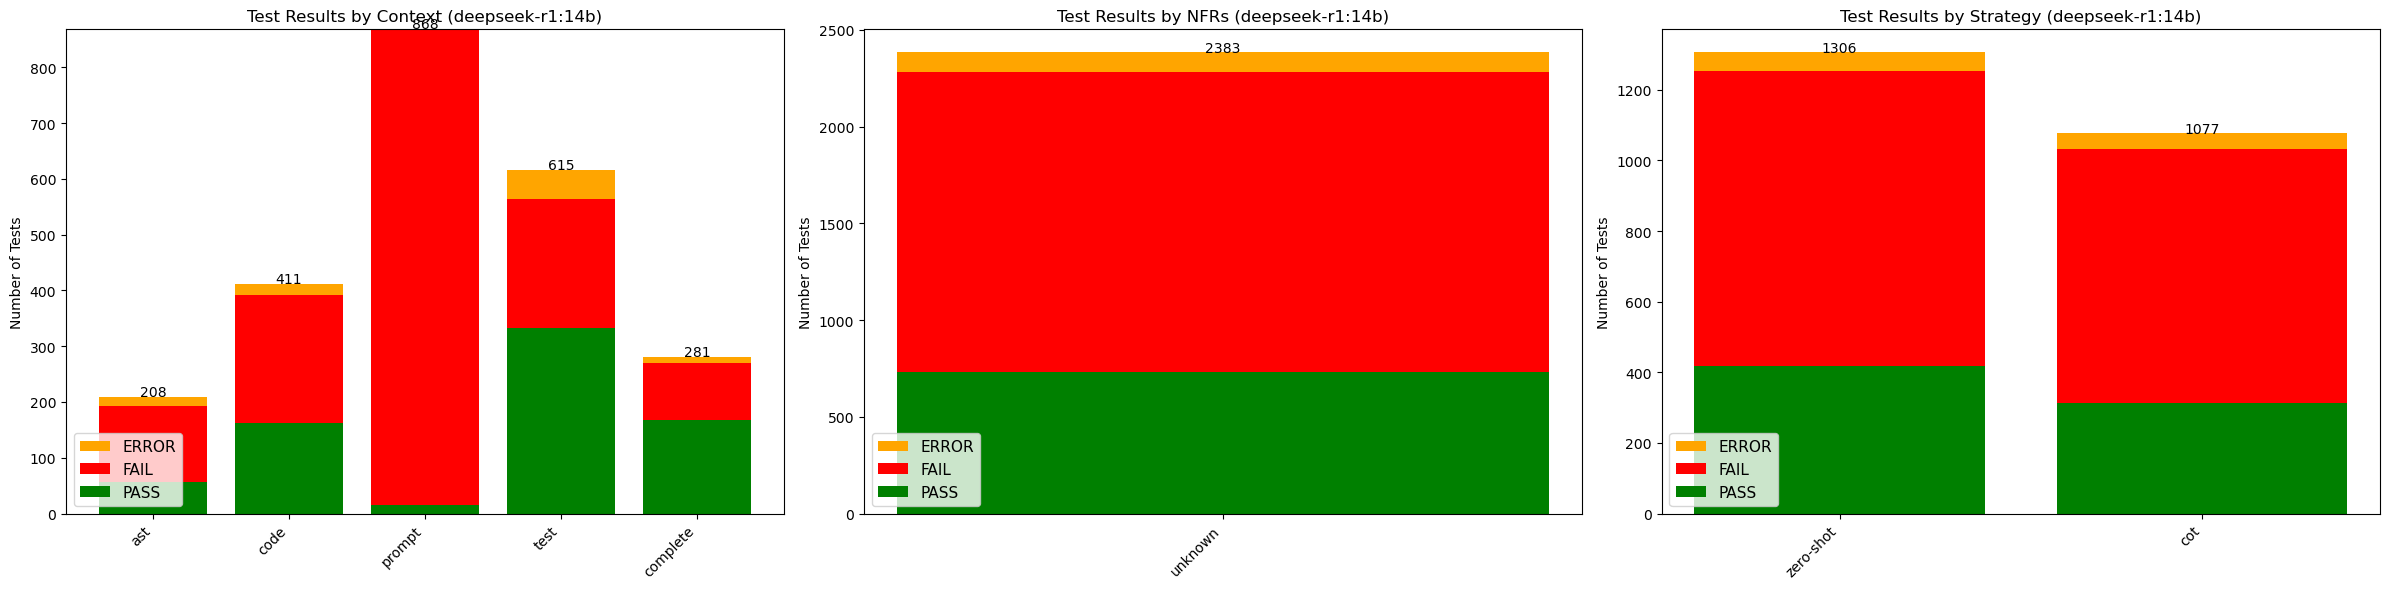

In [170]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(FILTERED_PATH_CODEBLEU, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# Identify models
models = set()
for entry in dataset:
    for clone in entry.get("clones", []):
        models.add(clone.get("model", "unknown"))
models = sorted(models)

for model in models:
    grouped_by_context = {}
    grouped_by_nfrs = {}
    grouped_by_strategy = {}  # <-- new

    for entry in dataset:
        # Determine expected number of tests
        if entry.get("clones"):
            num_tests = max(len(clone.get("test_results", {})) for clone in entry["clones"])
        else:
            num_tests = 0

        for clone in entry.get("clones", []):
            if clone.get("model") != model:
                continue

            context = clone.get("context", "unknown")
            nfrs = clone.get("nfrs", "unknown")
            strategy = clone.get("strategy", "unknown")  # <-- new
            results = clone.get("test_results", {})

            # Fill missing tests as ERROR
            if len(results) < num_tests:
                missing = num_tests - len(results)
                for i in range(missing):
                    results[f"missing_test_{i+1}"] = "ERROR"

            # --- Group by context ---
            if context not in grouped_by_context:
                grouped_by_context[context] = {"PASS": 0, "FAIL": 0, "ERROR": 0}
            for status in results.values():
                status = status.upper()
                if status in ["PASS", "FAIL", "ERROR"]:
                    grouped_by_context[context][status] += 1

            # --- Group by NFR ---
            if nfrs not in grouped_by_nfrs:
                grouped_by_nfrs[nfrs] = {"PASS": 0, "FAIL": 0, "ERROR": 0}
            for status in results.values():
                status = status.upper()
                if status in ["PASS", "FAIL", "ERROR"]:
                    grouped_by_nfrs[nfrs][status] += 1

            # --- Group by strategy ---
            if strategy not in grouped_by_strategy:
                grouped_by_strategy[strategy] = {"PASS": 0, "FAIL": 0, "ERROR": 0}
            for status in results.values():
                status = status.upper()
                if status in ["PASS", "FAIL", "ERROR"]:
                    grouped_by_strategy[strategy][status] += 1

    # Helper function to prepare data
    def prepare_data(grouped_dict):
        filters = list(grouped_dict.keys())
        passes = [grouped_dict[h]["PASS"] for h in filters]
        fails  = [grouped_dict[h]["FAIL"] for h in filters]
        errors = [grouped_dict[h]["ERROR"] for h in filters]
        return filters, passes, fails, errors

    # Prepare data
    filters_context, passes_context, fails_context, errors_context = prepare_data(grouped_by_context)
    filters_nfrs, passes_nfrs, fails_nfrs, errors_nfrs = prepare_data(grouped_by_nfrs)
    filters_strategy, passes_strategy, fails_strategy, errors_strategy = prepare_data(grouped_by_strategy)

    # Create subplots (3 panels)
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))

    # --- Plot context ---
    x_context = range(len(filters_context))
    axes[0].bar(x_context, passes_context, color="green", label="PASS")
    axes[0].bar(x_context, fails_context, bottom=passes_context, color="red", label="FAIL")
    axes[0].bar(x_context, errors_context, bottom=[p+f for p,f in zip(passes_context, fails_context)], color="orange", label="ERROR")
    axes[0].set_xticks(x_context)
    axes[0].set_xticklabels(filters_context, rotation=45, ha="right")
    axes[0].set_ylabel("Number of Tests")
    axes[0].set_title(f"Test Results by Context ({model})")
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles[::-1], labels[::-1], fontsize=11, loc="lower left")
    for i, (p,f,e) in enumerate(zip(passes_context, fails_context, errors_context)):
        total = p+f+e
        axes[0].text(i, total+2, str(total), ha="center", fontsize=10)

    # --- Plot NFRs ---
    x_nfrs = range(len(filters_nfrs))
    axes[1].bar(x_nfrs, passes_nfrs, color="green", label="PASS")
    axes[1].bar(x_nfrs, fails_nfrs, bottom=passes_nfrs, color="red", label="FAIL")
    axes[1].bar(x_nfrs, errors_nfrs, bottom=[p+f for p,f in zip(passes_nfrs, fails_nfrs)], color="orange", label="ERROR")
    axes[1].set_xticks(x_nfrs)
    axes[1].set_xticklabels(filters_nfrs, rotation=45, ha="right")
    axes[1].set_ylabel("Number of Tests")
    axes[1].set_title(f"Test Results by NFRs ({model})")
    handles, labels = axes[1].get_legend_handles_labels()
    axes[1].legend(handles[::-1], labels[::-1], fontsize=11, loc="lower left")
    for i, (p,f,e) in enumerate(zip(passes_nfrs, fails_nfrs, errors_nfrs)):
        total = p+f+e
        axes[1].text(i, total+2, str(total), ha="center", fontsize=10)

    # --- Plot Strategy ---
    x_strategy = range(len(filters_strategy))
    axes[2].bar(x_strategy, passes_strategy, color="green", label="PASS")
    axes[2].bar(x_strategy, fails_strategy, bottom=passes_strategy, color="red", label="FAIL")
    axes[2].bar(x_strategy, errors_strategy, bottom=[p+f for p,f in zip(passes_strategy, fails_strategy)], color="orange", label="ERROR")
    axes[2].set_xticks(x_strategy)
    axes[2].set_xticklabels(filters_strategy, rotation=45, ha="right")
    axes[2].set_ylabel("Number of Tests")
    axes[2].set_title(f"Test Results by Strategy ({model})")
    handles, labels = axes[2].get_legend_handles_labels()
    axes[2].legend(handles[::-1], labels[::-1], fontsize=11, loc="lower left")
    for i, (p,f,e) in enumerate(zip(passes_strategy, fails_strategy, errors_strategy)):
        total = p+f+e
        axes[2].text(i, total+2, str(total), ha="center", fontsize=10)

    plt.tight_layout()
    plt.show()


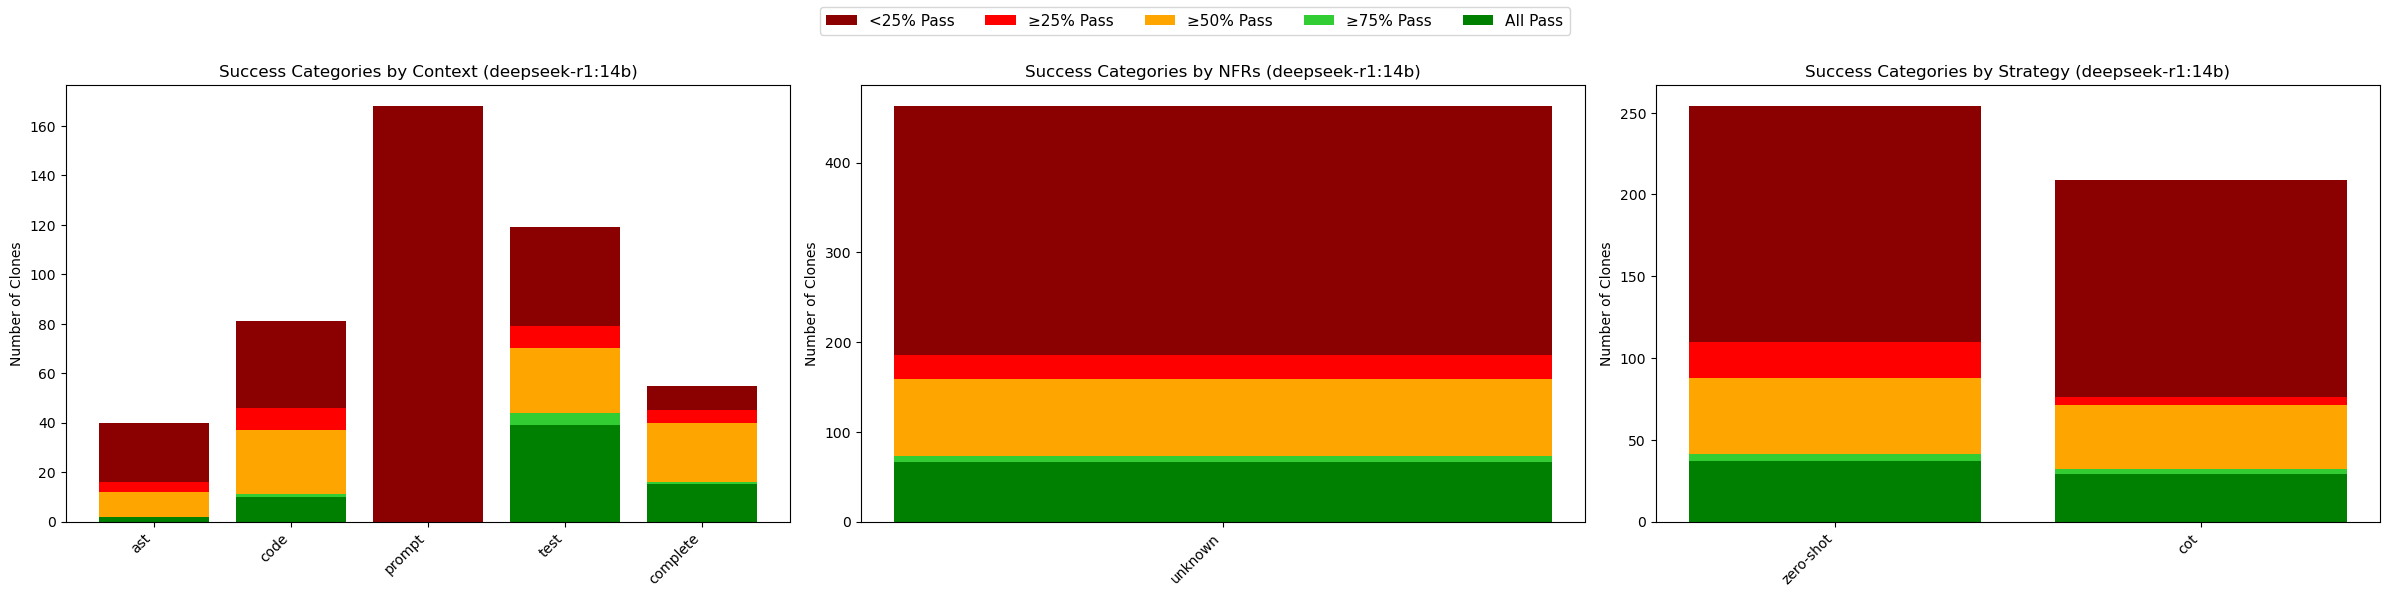

In [171]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(FILTERED_PATH_CODEBLEU, "r", encoding="utf-8") as f:
    dataset = json.load(f)

categories = ["All Pass", "≥75% Pass", "≥50% Pass", "≥25% Pass", "<25% Pass"]
colors = ["green", "limegreen", "orange", "red", "darkred"]

def classify_clone(results, num_tests):
    num_pass = sum(1 for v in results.values() if v.upper() == "PASS")
    ratio = num_pass / num_tests if num_tests > 0 else 0

    if ratio == 1.0:
        return "All Pass"
    elif ratio >= 0.75:
        return "≥75% Pass"
    elif ratio >= 0.50:
        return "≥50% Pass"
    elif ratio >= 0.25:
        return "≥25% Pass"
    else:
        return "<25% Pass"

def plot_grouped(ax, grouped_dict):
    filters = list(grouped_dict.keys())
    x = range(len(filters))

    bottoms = [0] * len(filters)
    for cat, color in zip(categories, colors):
        values = [grouped_dict[f][cat] for f in filters]
        ax.bar(x, values, bottom=bottoms, label=cat, color=color)
        bottoms = [b + v for b, v in zip(bottoms, values)]

    ax.set_xticks(x)
    ax.set_xticklabels(filters, rotation=45, ha="right", fontsize=10)
    ax.set_ylabel("Number of Clones")
    return ax

# Detect all models present
models = sorted({clone.get("model", "unknown") for entry in dataset for clone in entry.get("clones", [])})

# One figure per model
for model in models:
    grouped_context = {}
    grouped_nfrs = {}
    grouped_strategy = {}  # <-- new

    for entry in dataset:
        num_tests = max((len(clone.get("test_results", {})) for clone in entry.get("clones", [])), default=0)

        for clone in entry.get("clones", []):
            if clone.get("model") != model:
                continue

            context = clone.get("context", "unknown")
            nfrs = clone.get("nfrs", "unknown")
            strategy = clone.get("strategy", "unknown")  # <-- new
            results = clone.get("test_results", {})

            # Fill missing tests as ERROR
            for i in range(num_tests - len(results)):
                results[f"missing_test_{i+1}"] = "ERROR"

            category = classify_clone(results, num_tests)

            # Group by context
            grouped_context.setdefault(context, {c: 0 for c in categories})
            grouped_context[context][category] += 1

            # Group by NFR
            grouped_nfrs.setdefault(nfrs, {c: 0 for c in categories})
            grouped_nfrs[nfrs][category] += 1

            # Group by strategy
            grouped_strategy.setdefault(strategy, {c: 0 for c in categories})
            grouped_strategy[strategy][category] += 1

    # Plot for this model (3 panels)
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    plot_grouped(axes[0], grouped_context).set_title(f"Success Categories by Context ({model})")
    plot_grouped(axes[1], grouped_nfrs).set_title(f"Success Categories by NFRs ({model})")
    plot_grouped(axes[2], grouped_strategy).set_title(f"Success Categories by Strategy ({model})")

    # Unified legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles[::-1], labels[::-1], fontsize=11, loc="upper center", ncol=len(categories))

    plt.tight_layout(rect=[0, 0, 1, 0.92])  # leave space for legend
    plt.show()


## Summary

### Dataset filtered by original code 

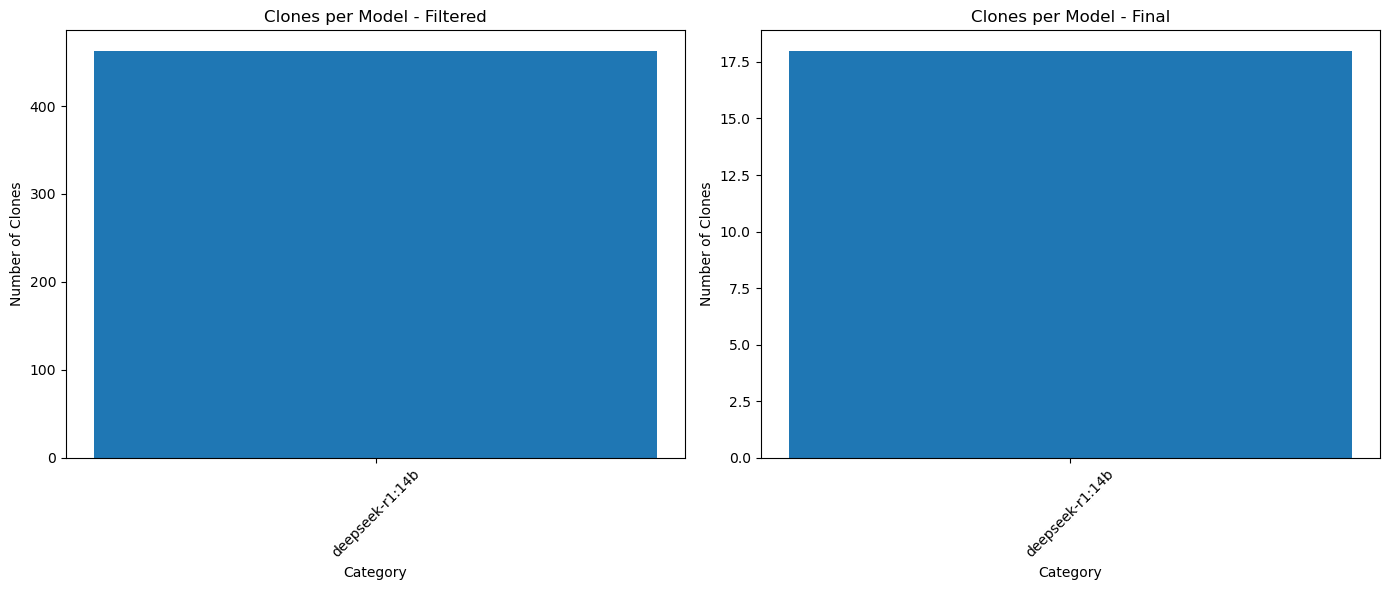

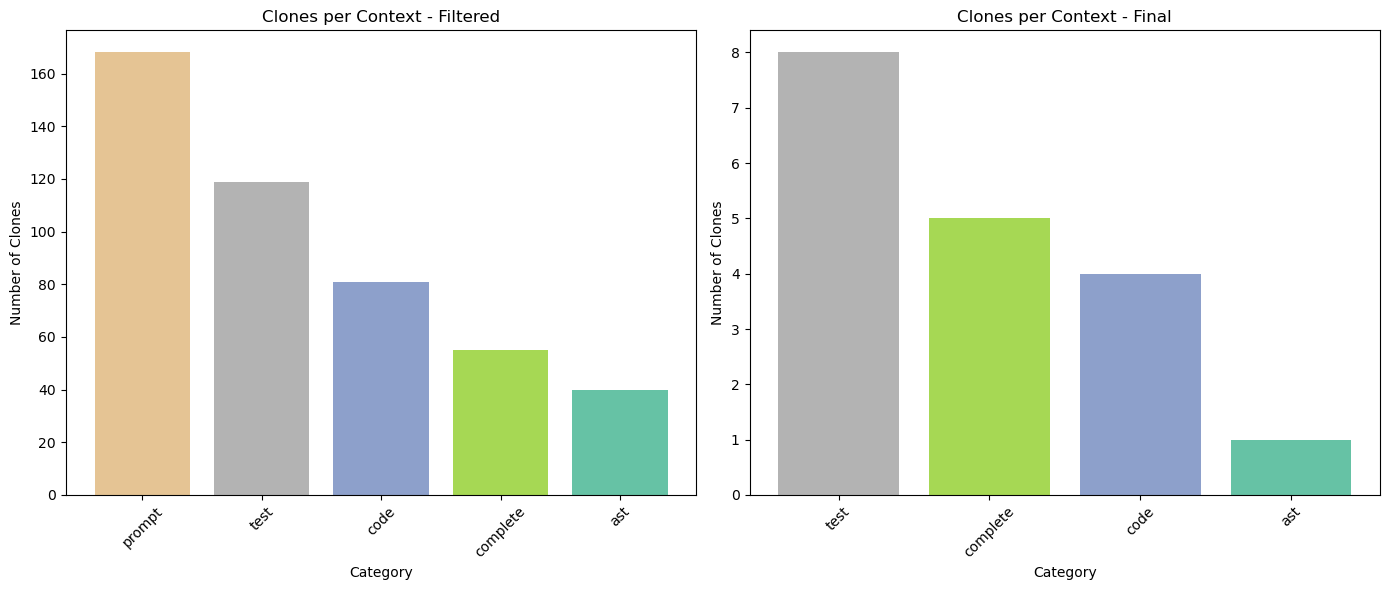

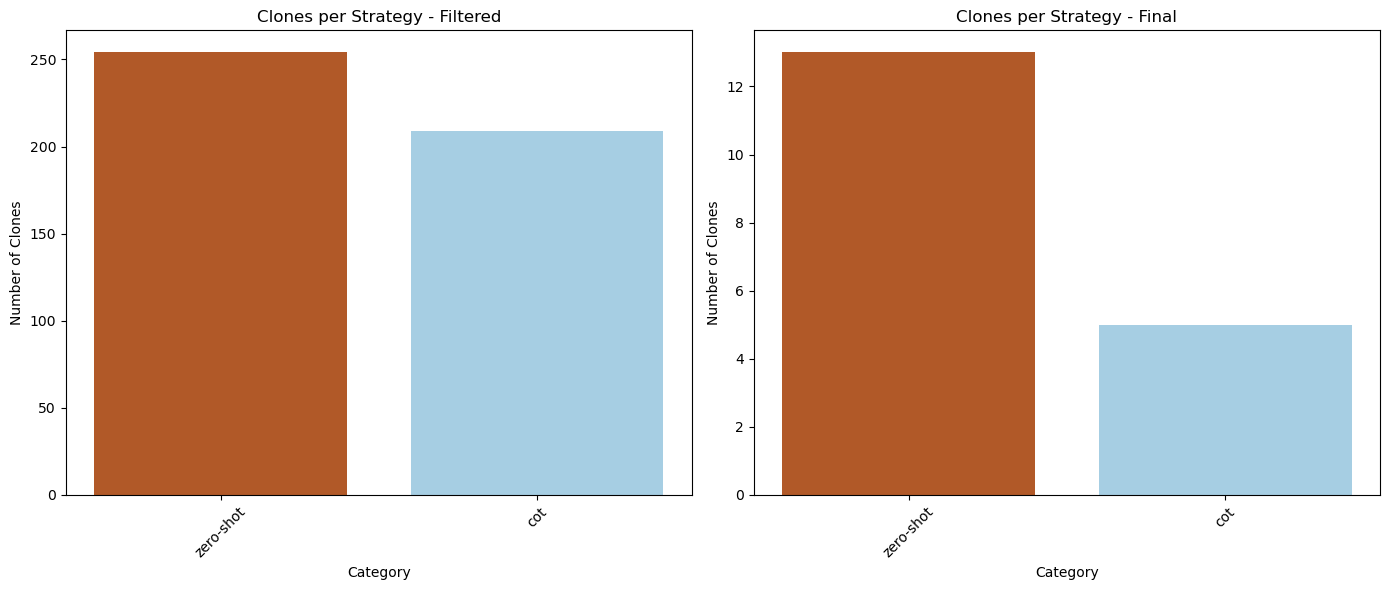

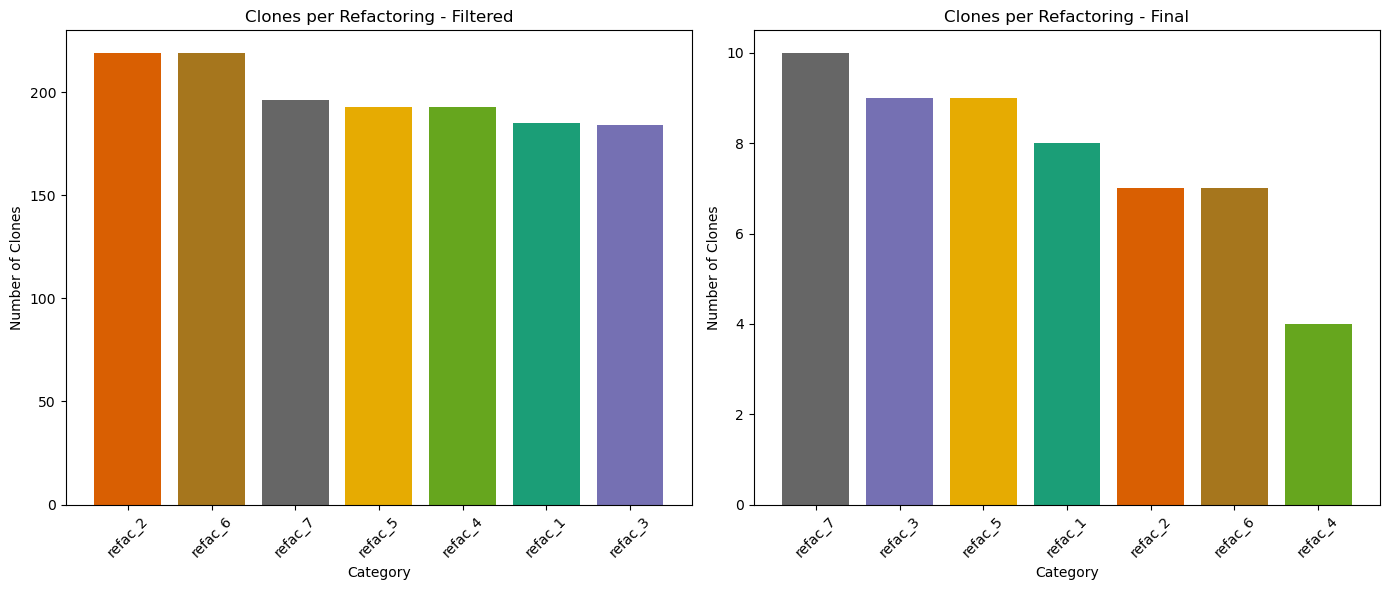

In [173]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import json
from collections import Counter

# ✅ Define a fixed global color palette for consistency
FIXED_COLORS = {
    "models": plt.cm.tab10,
    "contexts": plt.cm.Set2,
    "strategies": plt.cm.Paired,
    "refacs": plt.cm.Dark2
}

def get_fixed_colors(labels, cmap):
    """Assign consistent colors to each label based on sorted order."""
    n = len(labels)
    return {label: cmap(i / max(1, n - 1)) for i, label in enumerate(sorted(labels))}

def plot_comparison(counter1, counter2, title, label1="Dataset 1", label2="Dataset 2", cmap=plt.cm.tab10):
    """Plot two bar charts side by side for comparison (same as before but with fixed colors)."""
    # Sort counters descending
    sorted1 = sorted(counter1.items(), key=lambda x: x[1], reverse=True)
    sorted2 = sorted(counter2.items(), key=lambda x: x[1], reverse=True)

    labels1, values1 = zip(*sorted1) if sorted1 else ([], [])
    labels2, values2 = zip(*sorted2) if sorted2 else ([], [])

    # ✅ Build color map based on all unique labels from both datasets
    all_labels = sorted(set(labels1) | set(labels2))
    color_map = get_fixed_colors(all_labels, cmap)

    colors1 = [color_map[label] for label in labels1]
    colors2 = [color_map[label] for label in labels2]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

    # Left plot
    axes[0].bar(labels1, values1, color=colors1)
    axes[0].set_title(f"{title} - {label1}")
    axes[0].set_xlabel("Category")
    axes[0].set_ylabel("Number of Clones")
    axes[0].tick_params(axis="x", rotation=45)

    # Right plot
    axes[1].bar(labels2, values2, color=colors2)
    axes[1].set_title(f"{title} - {label2}")
    axes[1].set_xlabel("Category")
    axes[1].set_ylabel("Number of Clones")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

def summarize_clones(data):
    model_counts = Counter()
    context_counts = Counter()
    strategy_counts = Counter()
    refac_counts = Counter()

    for entry in data:
        for clone in entry.get("clones", []):
            model_counts[clone.get("model", "Unknown")] += 1
            context_counts[clone.get("context", "Unknown")] += 1
            strategy_counts[clone.get("strategy", "Unknown")] += 1

            # ✅ Handle list of refactorings (refacs)
            refacs = clone.get("refacs", [])
            if isinstance(refacs, list):
                for ref in refacs:
                    refac_counts[ref] += 1
            elif isinstance(refacs, str):  # in case it's a single string
                refac_counts[refacs] += 1

    return {
        "models": model_counts,
        "contexts": context_counts,
        "strategies": strategy_counts,
        "refacs": refac_counts
    }

# Load datasets
with open(FILTERED_PATH_CODEBLEU, "r") as f:
    data1 = json.load(f)
with open(FINAL_DATASET, "r") as f:
    data2 = json.load(f)

if isinstance(data1, dict):
    data1 = [data1]
if isinstance(data2, dict):
    data2 = [data2]

summary1 = summarize_clones(data1)
summary2 = summarize_clones(data2)

# ✅ Use fixed color schemes per category type
plot_comparison(summary1["models"], summary2["models"], "Clones per Model", "Filtered", "Final", cmap=FIXED_COLORS["models"])
plot_comparison(summary1["contexts"], summary2["contexts"], "Clones per Context", "Filtered", "Final", cmap=FIXED_COLORS["contexts"])
plot_comparison(summary1["strategies"], summary2["strategies"], "Clones per Strategy", "Filtered", "Final", cmap=FIXED_COLORS["strategies"])
plot_comparison(summary1["refacs"], summary2["refacs"], "Clones per Refactoring", "Filtered", "Final", cmap=FIXED_COLORS["refacs"])


## Efficiency scores

✅ Efficiency summary saved to ../results/efficiency_summary.csv


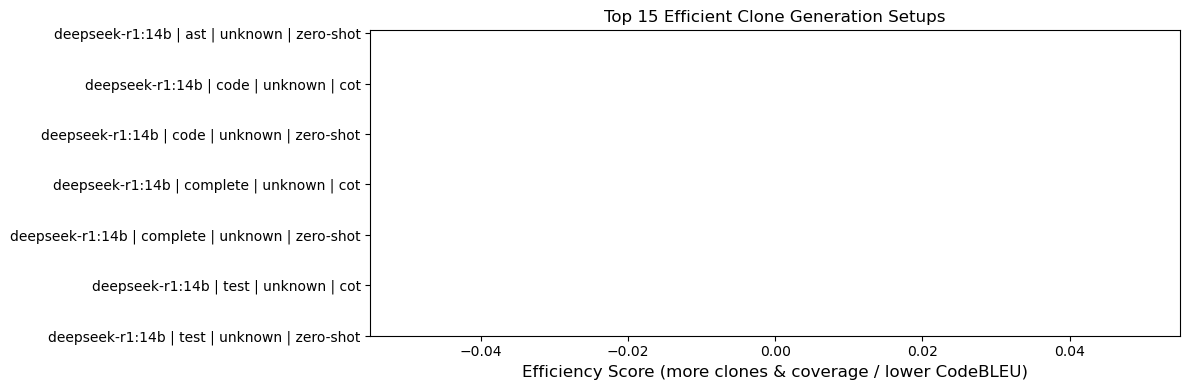

In [174]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# === Load dataset ===
with open(FINAL_DATASET, "r", encoding="utf-8") as f:
    dataset = json.load(f)

records = []
for entry in dataset:
    entry_id = entry["id"]
    for clone in entry.get("clones", []):
        codebleu_score = (
            clone.get("metrics", {})
                 .get("codebleu", {})
                 .get("originalcode", None)
        )

        records.append({
            "entry_id": entry_id,
            "model": clone.get("model", "unknown"),
            "context": clone.get("context", "unknown"),
            "nfrs": clone.get("nfrs", "unknown"),
            "strategy": clone.get("strategy", "unknown"),
            "codebleu_original": codebleu_score
        })

df = pd.DataFrame(records)

# === Summarize per setup ===
summary = (
    df.groupby(["model", "context", "nfrs", "strategy"])
      .agg(
          total_clones=("entry_id", "count"),
          entries_covered=("entry_id", pd.Series.nunique),
          avg_codebleu=("codebleu_original", "mean")
      )
      .reset_index()
)

# Define efficiency score: more clones on more entries + lower codebleu (more diverse)
summary["efficiency_score"] = (
    (summary["total_clones"] / summary["entries_covered"])
    / (summary["avg_codebleu"] + 1e-9)
)

# Round for readability
summary["avg_codebleu"] = summary["avg_codebleu"].round(3)
summary["efficiency_score"] = summary["efficiency_score"].round(3)

# Sort by efficiency
summary = summary.sort_values(by="efficiency_score", ascending=False)

# === Save summary ===
csv_out = "../results/efficiency_summary.csv"
summary.to_csv(csv_out, index=False)
print(f"✅ Efficiency summary saved to {csv_out}")

# === Plot top 15 setups ===
top_n = 15
plot_data = summary.head(top_n)

plt.figure(figsize=(12, 4))
bars = plt.barh(
    y=plot_data.index.astype(str),
    width=plot_data["efficiency_score"],
    color="seagreen"
)

plt.yticks(
    ticks=plot_data.index.astype(str),
    labels=[
        f"{row.model} | {row.context} | {row.nfrs} | {row.strategy}"
        for _, row in plot_data.iterrows()
    ]
)

plt.xlabel("Efficiency Score (more clones & coverage / lower CodeBLEU)", fontsize=12)
plt.title(f"Top {top_n} Efficient Clone Generation Setups")
plt.gca().invert_yaxis()  # Highest on top

# Annotate bars with values
for bar, score in zip(bars, plot_data["efficiency_score"]):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f"{score:.2f}", va="center")

plt.tight_layout() 
plt.show()


In [175]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# === Config ===
ORIGINAL_WEIGHT = 3.0  # give original more importance
TOP_N = 15

# === Load dataset ===
with open(FINAL_DATASET, "r", encoding="utf-8") as f:
    dataset = json.load(f)

records = []
for entry in dataset:
    entry_id = entry["id"]
    for clone in entry.get("clones", []):
        codebleu_dict = clone.get("metrics", {}).get("codebleu", {})

        if not codebleu_dict:
            continue

        # Weighted average of CodeBLEU scores
        original_score = codebleu_dict.get("originalcode", None)
        other_scores = [v for k, v in codebleu_dict.items() if k != "originalcode"]

        weighted_sum = 0.0
        total_weight = 0.0

        if original_score is not None:
            weighted_sum += ORIGINAL_WEIGHT * original_score
            total_weight += ORIGINAL_WEIGHT

        if other_scores:
            weighted_sum += sum(other_scores)
            total_weight += len(other_scores)

        avg_codebleu = weighted_sum / total_weight if total_weight > 0 else None

        records.append({
            "entry_id": entry_id,
            "model": clone.get("model", "unknown"),
            "context": clone.get("context", "unknown"),
            "nfrs": clone.get("nfrs", "unknown"),
            "strategy": clone.get("strategy", "unknown"),
            "avg_codebleu": avg_codebleu
        })

df = pd.DataFrame(records)

# === Summarize per setup ===
summary = (
    df.groupby(["model", "context", "nfrs", "strategy"])
      .agg(
          total_clones=("entry_id", "count"),
          entries_covered=("entry_id", pd.Series.nunique),
          avg_codebleu=("avg_codebleu", "mean")
      )
      .reset_index()
)

# Efficiency: more clones across more entries, lower avg_codebleu
summary["efficiency_score"] = (
    (summary["total_clones"] / summary["entries_covered"])
    / (summary["avg_codebleu"] + 1e-9)
)

# Round
summary["avg_codebleu"] = summary["avg_codebleu"].round(3)
summary["efficiency_score"] = summary["efficiency_score"].round(3)

# Sort
summary = summary.sort_values(by="efficiency_score", ascending=False)

# === Save summary ===
csv_out = "../results/efficiency_summary_weighted.csv"
summary.to_csv(csv_out, index=False)
print(f"✅ Efficiency summary saved to {csv_out}")

# === Plot top setups ===
plot_data = summary.head(TOP_N)

plt.figure(figsize=(12, 4))
bars = plt.barh(
    y=plot_data.index.astype(str),
    width=plot_data["efficiency_score"],
    color="seagreen"
)

plt.yticks(
    ticks=plot_data.index.astype(str),
    labels=[
        f"{row.model} | {row.context} | {row.nfrs} | {row.strategy}"
        for _, row in plot_data.iterrows()
    ]
)

plt.xlabel("Efficiency Score (clones & coverage / weighted CodeBLEU)")
plt.title(f"Top {TOP_N} Efficient Clone Generation Setups")
plt.gca().invert_yaxis()

for bar, score in zip(bars, plot_data["efficiency_score"]):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f"{score:.2f}", va="center")

plt.tight_layout() 
plt.show()


KeyError: 'model'

## Driving factors

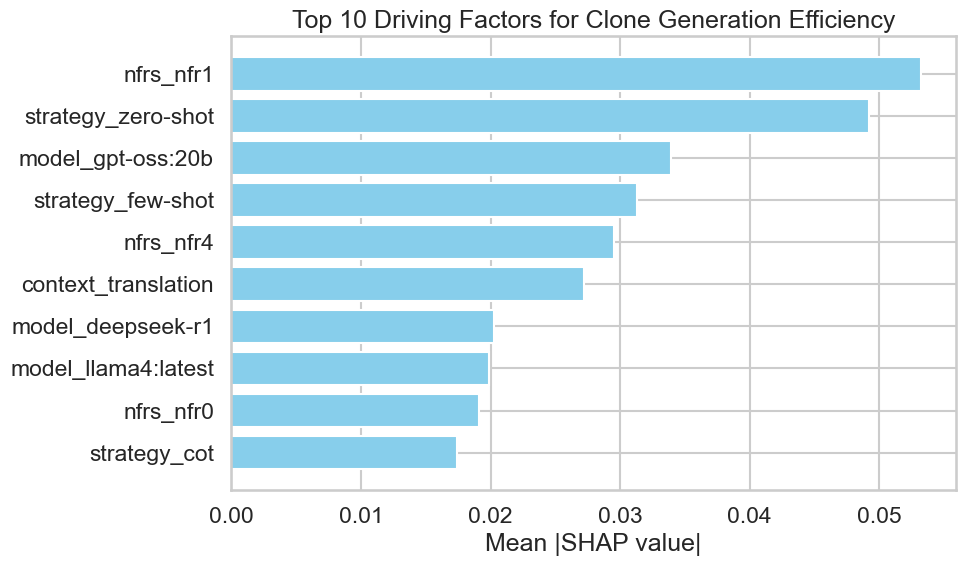

Top 10 driving factors:
                feature  importance
13            nfrs_nfr1    0.053250
20   strategy_zero-shot    0.049167
2     model_gpt-oss:20b    0.033896
19    strategy_few-shot    0.031301
16            nfrs_nfr4    0.029493
10  context_translation    0.027242
0     model_deepseek-r1    0.020267
5   model_llama4:latest    0.019845
12            nfrs_nfr0    0.019070
18         strategy_cot    0.017413


In [ ]:
import json
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt

# === Load dataset ===
with open(FINAL_DATASET, "r", encoding="utf-8") as f:
    dataset = json.load(f)

records = []
ORIGINAL_WEIGHT = 3.0  # weight for original code in avg_codebleu

for entry in dataset:
    entry_id = entry["id"]
    for clone in entry.get("clones", []):
        codebleu_dict = clone.get("metrics", {}).get("codebleu", {})
        if not codebleu_dict:
            continue

        original_score = codebleu_dict.get("originalcode", 0.0)
        other_scores = [v for k, v in codebleu_dict.items() if k != "originalcode"]

        weighted_sum = ORIGINAL_WEIGHT * original_score + sum(other_scores)
        total_weight = ORIGINAL_WEIGHT + len(other_scores)
        avg_codebleu = weighted_sum / total_weight if total_weight > 0 else 0.0

        # Efficiency proxy: more diverse clones = higher score
        efficiency_score = 1.0 / (avg_codebleu + 1e-9)

        records.append({
            "model": clone.get("model", "unknown"),
            "context": clone.get("context", "unknown"),
            "nfrs": clone.get("nfrs", "unknown"),
            "strategy": clone.get("strategy", "unknown"),
            "efficiency_score": efficiency_score
        })

df = pd.DataFrame(records)

# === One-hot encode categorical variables ===
X = df[["model", "context", "nfrs", "strategy"]]
y = df["efficiency_score"]

encoder = OneHotEncoder(sparse_output=False)
X_encoded = encoder.fit_transform(X)

# === Train Random Forest ===
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_encoded, y)

# === SHAP analysis ===
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_encoded)

# Aggregate mean absolute SHAP values for feature importance
feature_names = encoder.get_feature_names_out(X.columns)
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": abs(shap_values).mean(axis=0)
}).sort_values(by="importance", ascending=False)

# === Plot top 10 driving factors ===
plt.figure(figsize=(10,6))
plt.barh(
    y=importance_df["feature"].head(10),
    width=importance_df["importance"].head(10),
    color="skyblue"
)
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP value|")
plt.title("Top 10 Driving Factors for Clone Generation Efficiency")
plt.tight_layout()
plt.show()

# === Print top factors ===
print("Top 10 driving factors:")
print(importance_df.head(10))


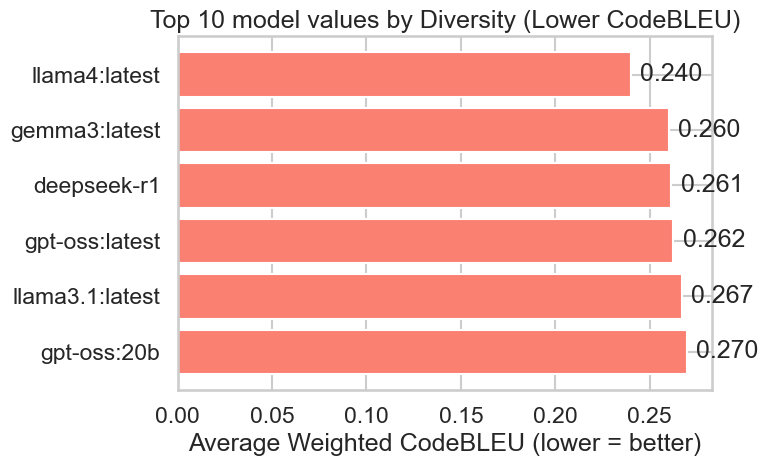

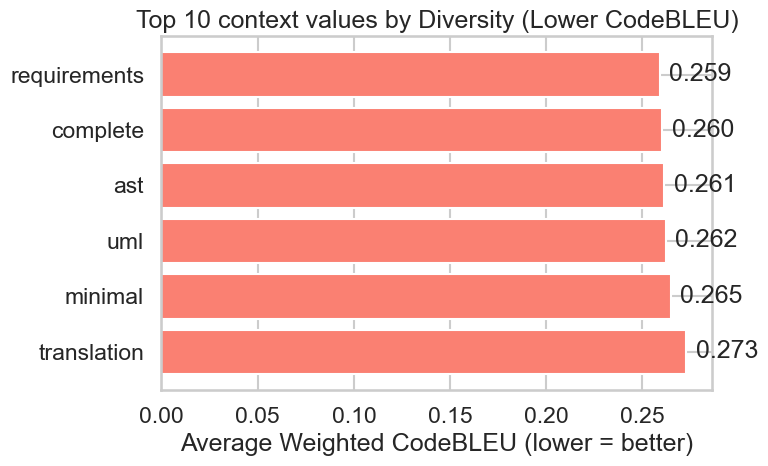

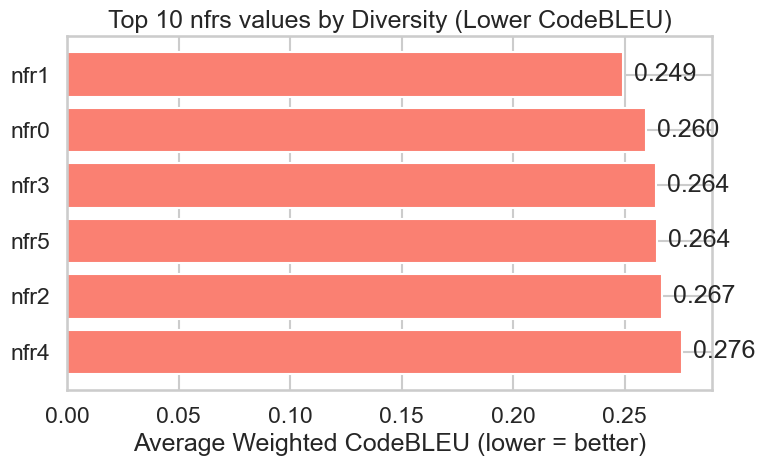

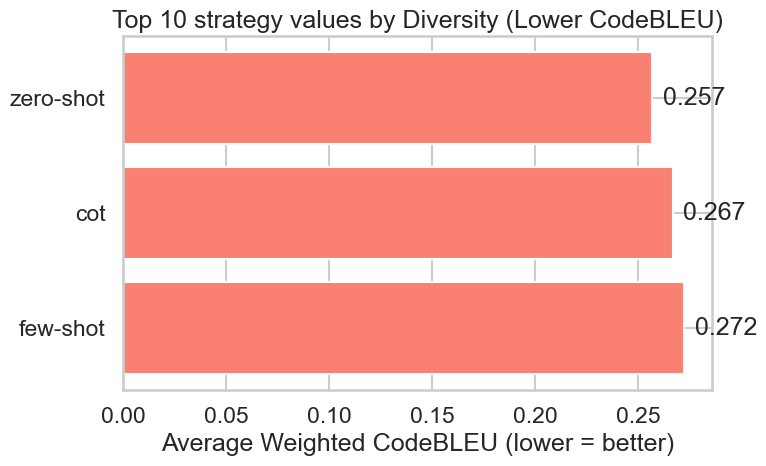

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# === Load dataset ===
with open(FINAL_DATASET, "r", encoding="utf-8") as f:
    dataset = json.load(f)

records = []
ORIGINAL_WEIGHT = 3.0  # weight for original code in avg_codebleu

for entry in dataset:
    for clone in entry.get("clones", []):
        codebleu_dict = clone.get("metrics", {}).get("codebleu", {})
        if not codebleu_dict:
            continue

        original_score = codebleu_dict.get("originalcode", 0.0)
        other_scores = [v for k, v in codebleu_dict.items() if k != "originalcode"]

        weighted_sum = ORIGINAL_WEIGHT * original_score + sum(other_scores)
        total_weight = ORIGINAL_WEIGHT + len(other_scores)
        avg_codebleu = weighted_sum / total_weight if total_weight > 0 else 0.0

        records.append({
            "model": clone.get("model", "unknown"),
            "context": clone.get("context", "unknown"),
            "nfrs": clone.get("nfrs", "unknown"),
            "strategy": clone.get("strategy", "unknown"),
            "avg_codebleu": avg_codebleu
        })

df = pd.DataFrame(records)

def plot_factor(df, factor, top_n=10):
    # sort by ascending avg_codebleu (lower is better)
    summary = df.groupby(factor)["avg_codebleu"].mean().sort_values(ascending=True)
    summary = summary.head(top_n)    
    plt.figure(figsize=(8, 5))
    plt.barh(summary.index.astype(str), summary.values, color="salmon")
    plt.gca().invert_yaxis()  # lowest CodeBLEU at the top
    plt.xlabel("Average Weighted CodeBLEU (lower = better)")
    plt.title(f"Top {top_n} {factor} values by Diversity (Lower CodeBLEU)")
    
    # annotate bars
    for i, val in enumerate(summary.values):
        plt.text(val + 0.005, i, f"{val:.3f}", va='center')
    
    plt.tight_layout()
    plt.show()


# === Plot each factor ===
for factor in ["model", "context", "nfrs", "strategy"]:
    plot_factor(df, factor, top_n=10)
